# Анализ данных DEPD (new_format_data)

Разведочный анализ корпуса скользящих окон ЭЭГ:
- объём и структура данных;
- train/test split по пациентам (80/20, stratified);
- распределение DEPD, эпизодов и состояний (сон / бодрствование).

In [1]:
from __future__ import annotations

import json
import pickle
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

%matplotlib inline

NB_DIR = Path.cwd().resolve()
REPO = None
for candidate in NB_DIR.parents:
    if (candidate / "new_format_data" / "metadata.pkl").is_file():
        REPO = candidate
        break
if REPO is None:
    raise FileNotFoundError("new_format_data/metadata.pkl not found")

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from riemann_new_format.dataset import load_split

DATA_DIR = REPO / "new_format_data"
GLOBAL_DB = REPO / "global_EEG_processed_DB_bipolar"
SPLIT_PATH = DATA_DIR / "splits" / "patient_split_80_20.json"
FIGURES_DIR = NB_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "train": "#2E86AB",
    "test": "#E94F37",
    "depd": "#F6AE2D",
    "background": "#CBD5E1",
    "sleep": "#5B6C9F",
    "awake": "#7CB518",
}

CH_NAMES = [
    "Fp1-F7", "F7-T3", "T3-T5", "T5-O1", "Fp1-F3", "F3-C3", "C3-P3", "P3-O1",
    "Fp2-F8", "F8-T4", "T4-T6", "T6-O2", "Fp2-F4", "F4-C4", "C4-P4", "P4-O2",
    "Fz-Cz", "Cz-Pz",
]

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print("REPO:", REPO)
print("FIGURES ->", FIGURES_DIR)

REPO: /Users/vspyatochkin/diploma_MAG
FIGURES -> /Users/vspyatochkin/diploma_MAG/diploma_dev_git/Diploma/notebooks/figures


## 1. Загрузка метаданных

In [2]:
with (DATA_DIR / "metadata.pkl").open("rb") as f:
    meta: list[dict] = pickle.load(f)

train_patients, test_patients = load_split(DATA_DIR)
train_set, test_set = set(train_patients), set(test_patients)

print(f"Окон в корпусе: {len(meta):,}")
print(f"Пациентов (external_id): {len({m['external_id'] for m in meta})}")
print(f"Split: {len(train_patients)} train / {len(test_patients)} test")
print(f"Split file: {SPLIT_PATH.name}")

Окон в корпусе: 1,029,244
Пациентов (external_id): 57
Split: 45 train / 12 test
Split file: patient_split_80_20.json


## 2. Сводка по корпусу

In [3]:
has_depd = np.array([bool(m["has_depd"]) for m in meta])
depd_frac = np.array([float(m["depd_frac"]) for m in meta])
states = Counter(m.get("state", "unknown") for m in meta)

summary = pd.DataFrame(
    {
        "Метрика": [
            "Всего окон",
            "DEPD-окон (has_depd)",
            "Доля DEPD-окон",
            "Окон с depd_frac ≥ 0.15",
            "Окон с depd_frac ≥ 0.50",
            "Полных DEPD (frac ≈ 1)",
            "Уникальных пациентов",
            "Уникальных record_id",
        ],
        "Значение": [
            f"{len(meta):,}",
            f"{has_depd.sum():,}",
            f"{has_depd.mean():.2%}",
            f"{(depd_frac >= 0.15).sum():,}",
            f"{(depd_frac >= 0.5).sum():,}",
            f"{(depd_frac >= 0.999).sum():,}",
            len({m["external_id"] for m in meta}),
            len({m.get("record_id") for m in meta}),
        ],
    }
)
display(summary)

print("Состояния (state):")
display(pd.Series(states).sort_values(ascending=False).to_frame("n_windows"))

,Метрика,Значение
0,Всего окон,"1,029,244"
1,DEPD-окон (has_depd),"44,153"
2,Доля DEPD-окон,4.29%
3,Окон с depd_frac ≥ 0.15,"34,683"
4,Окон с depd_frac ≥ 0.50,"4,557"
5,Полных DEPD (frac ≈ 1),38
6,Уникальных пациентов,57
7,Уникальных record_id,1


Состояния (state):


,n_windows
sleep,675504
awake,353740


## 3. Train / Test по пациентам

In [4]:
def patient_row(external_id: str) -> dict:
    rows = [m for m in meta if m["external_id"] == external_id]
    fracs = np.array([float(m["depd_frac"]) for m in rows])
    depd_mask = np.array([bool(m["has_depd"]) for m in rows])
    episodes = {
        (m["patient_id"], m.get("depd_interval_index"))
        for m in rows
        if m["has_depd"] and m.get("depd_interval_index") is not None
    }
    split = "test" if external_id in test_set else "train"
    return {
        "external_id": external_id,
        "split": split,
        "n_windows": len(rows),
        "n_depd": int(depd_mask.sum()),
        "depd_rate_pct": 100 * depd_mask.mean(),
        "n_episodes": len(episodes),
        "n_frac_ge_015": int((fracs >= 0.15).sum()),
        "sleep_pct": 100 * np.mean([m.get("state") == "sleep" for m in rows]),
    }


patients = sorted({m["external_id"] for m in meta})
df_pat = pd.DataFrame(patient_row(p) for p in patients)

split_stats = (
    df_pat.groupby("split")
    .agg(
        n_patients=("external_id", "count"),
        n_windows=("n_windows", "sum"),
        n_depd=("n_depd", "sum"),
        n_episodes=("n_episodes", "sum"),
        depd_rate_pct=("depd_rate_pct", "mean"),
    )
    .assign(depd_share=lambda x: 100 * x["n_depd"] / x["n_windows"])
    .round(2)
)
print("Агрегат по split:")
display(split_stats)

print("\nTest-пациенты:")
display(
    df_pat[df_pat.split == "test"]
    .sort_values("n_depd", ascending=False)
    .reset_index(drop=True)
)

Агрегат по split:


,n_patients,n_windows,n_depd,n_episodes,depd_rate_pct,depd_share
split,,,,,,
test,12,93654,7012,671,12.65,7.49
train,45,935590,37141,3405,20.08,3.97



Test-пациенты:


,external_id,split,n_windows,n_depd,depd_rate_pct,n_episodes,n_frac_ge_015,sleep_pct
0,patient_1.002_GA1501CO,test,30323,5551,18.306236,524,4418,56.580813
1,2.043_FA0015GR,test,16246,315,1.938939,22,244,23.962822
2,2.049_GA1500WQ,test,434,270,62.211982,30,211,100.000000
3,2.054_FA0182ZN,test,2434,253,10.394412,23,177,0.000000
4,2.045_GA1500X0,test,3653,188,5.146455,21,157,0.000000
5,2.023_FA0015HK,test,1562,127,8.130602,13,105,0.000000
6,2.013_FA0015MS,test,480,90,18.750000,10,70,100.000000
7,2.033_DA0236YJ,test,34484,72,0.208792,9,57,0.000000
8,2.025_DA0236T3,test,285,55,19.298246,5,43,100.000000
9,2.019_GA1500XN,test,1722,44,2.555168,7,33,100.000000


## 4. Визуализации

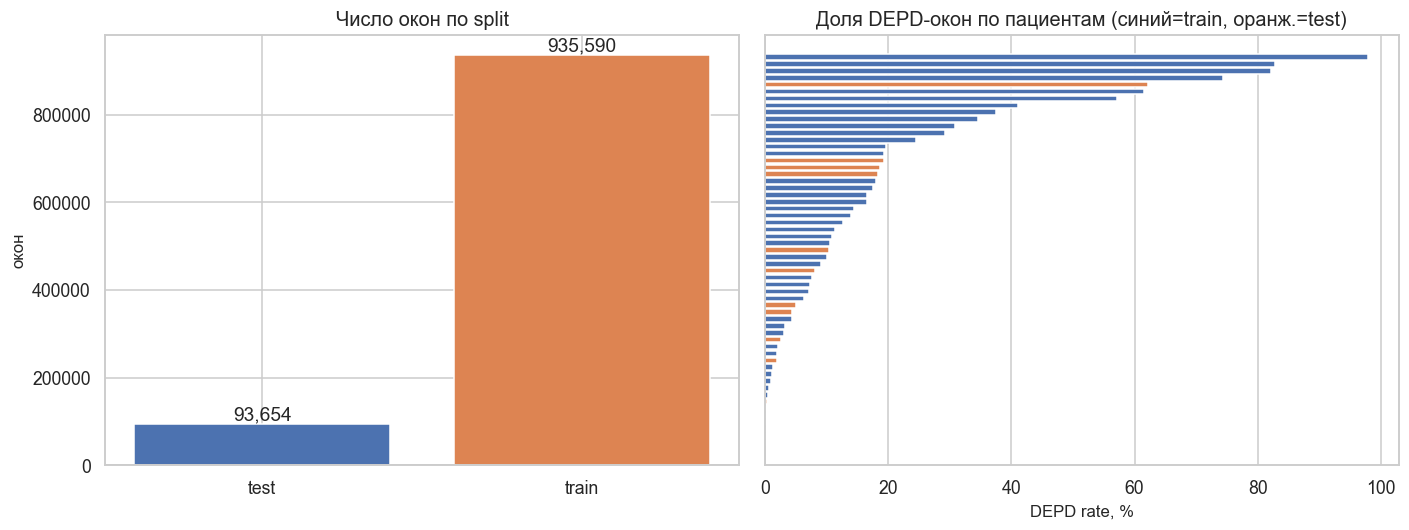

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Окна train vs test
split_windows = df_pat.groupby("split")["n_windows"].sum()
axes[0].bar(split_windows.index, split_windows.values, color=["#4C72B0", "#DD8452"])
axes[0].set_title("Число окон по split")
axes[0].set_ylabel("окон")
for i, v in enumerate(split_windows.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

# DEPD rate по пациентам
plot_df = df_pat.sort_values("depd_rate_pct", ascending=False)
colors = plot_df["split"].map({"train": "#4C72B0", "test": "#DD8452"})
axes[1].barh(range(len(plot_df)), plot_df["depd_rate_pct"], color=colors)
axes[1].set_yticks([])
axes[1].set_xlabel("DEPD rate, %")
axes[1].set_title("Доля DEPD-окон по пациентам (синий=train, оранж.=test)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

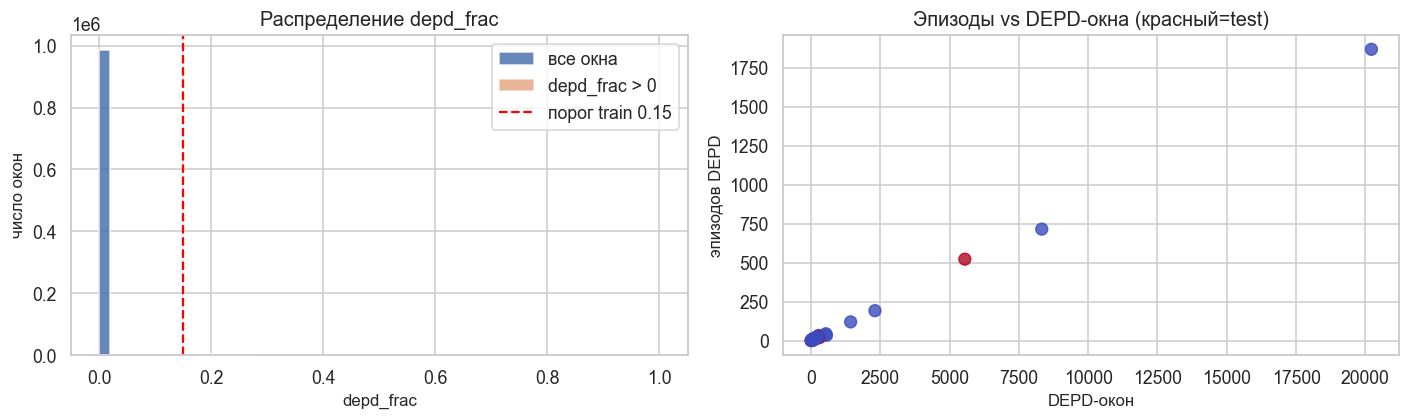

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Распределение depd_frac (лог-шкала частоты для хвоста)
depd_only = depd_frac[depd_frac > 0]
axes[0].hist(depd_frac, bins=50, color="#4C72B0", alpha=0.85, label="все окна")
axes[0].hist(depd_only, bins=50, color="#DD8452", alpha=0.6, label="depd_frac > 0")
axes[0].axvline(0.15, color="red", ls="--", lw=1.5, label="порог train 0.15")
axes[0].set_xlabel("depd_frac")
axes[0].set_ylabel("число окон")
axes[0].set_title("Распределение depd_frac")
axes[0].legend()

# Эпизоды vs DEPD-окна по пациентам
axes[1].scatter(
    df_pat["n_depd"],
    df_pat["n_episodes"],
    c=df_pat["split"].map({"train": 0, "test": 1}),
    cmap="coolwarm",
    alpha=0.8,
    s=60,
)
axes[1].set_xlabel("DEPD-окон")
axes[1].set_ylabel("эпизодов DEPD")
axes[1].set_title("Эпизоды vs DEPD-окна (красный=test)")
plt.tight_layout()
plt.show()

## 5. Global DB vs корпус окон

In [7]:
if GLOBAL_DB.joinpath("index.json").is_file():
    index = json.loads(GLOBAL_DB.joinpath("index.json").read_text(encoding="utf-8"))
    global_ids = {r["external_id"] for r in index["records"]}
    corpus_ids = set(df_pat["external_id"])
    db_summary = pd.DataFrame(
        {
            "Источник": ["global_EEG_processed_DB_bipolar", "new_format_data (корпус)"],
            "Записей / пациентов": [len(index["records"]), len(corpus_ids)],
            "В корпусе": ["—", len(corpus_ids & global_ids)],
            "Не в корпусе": [len(global_ids - corpus_ids), "—"],
        }
    )
    display(db_summary)
    if global_ids - corpus_ids:
        print("Примеры пациентов из global DB, не попавших в корпус:")
        print(sorted(global_ids - corpus_ids)[:8], "...")
else:
    print("global_EEG_processed_DB_bipolar/index.json не найден")

,Источник,Записей / пациентов,В корпусе,Не в корпусе
0,global_EEG_processed_DB_bipolar,78,—,21
1,new_format_data (корпус),57,57,—


Примеры пациентов из global DB, не попавших в корпус:
['000_FA0183FQ', '006_GA1500Z5', '007_GA150104', '2.012_DA0236UE', '2.014_FA0015MC', '2.014_FA0015ME', '2.014_FA0015MG', '2.014_FA0015MK'] ...


## 6. Параметры окна и split

In [8]:
sample = meta[0]
window_params = pd.DataFrame(
    {
        "Параметр": [
            "Длительность окна",
            "Шаг",
            "Частота дискретизации",
            "Каналов",
            "Отсчётов на канал",
            "Train patients",
            "Test patients",
            "random_state split",
        ],
        "Значение": [
            "1.0 с",
            "0.1 с",
            "200 Hz",
            "18 (bipolar)",
            "200",
            len(train_patients),
            len(test_patients),
            json.loads(SPLIT_PATH.read_text())["random_state"],
        ],
    }
)
display(window_params)

print("Train patients:", ", ".join(sorted(train_patients)[:5]), "...")
print("Test patients:", ", ".join(sorted(test_patients)))

,Параметр,Значение
0,Длительность окна,1.0 с
1,Шаг,0.1 с
2,Частота дискретизации,200 Hz
3,Каналов,18 (bipolar)
4,Отсчётов на канал,200
5,Train patients,45
6,Test patients,12
7,random_state split,42


Train patients: 000_FA0183FS, 005_FA0183ZO, 006_GA1500ZC, 007_GA150100, 008_GA15011B ...
Test patients: 2.013_FA0015MS, 2.015_FA0015L0, 2.019_GA1500XN, 2.023_FA0015HK, 2.025_DA0236T3, 2.027_DA0236YX, 2.033_DA0236YJ, 2.043_FA0015GR, 2.045_GA1500X0, 2.049_GA1500WQ, 2.054_FA0182ZN, patient_1.002_GA1501CO



Графики по структуре корпуса, разметке DEPD и примерам сигналов (без результатов модели).

Saved: 01_dashboard_overview.png


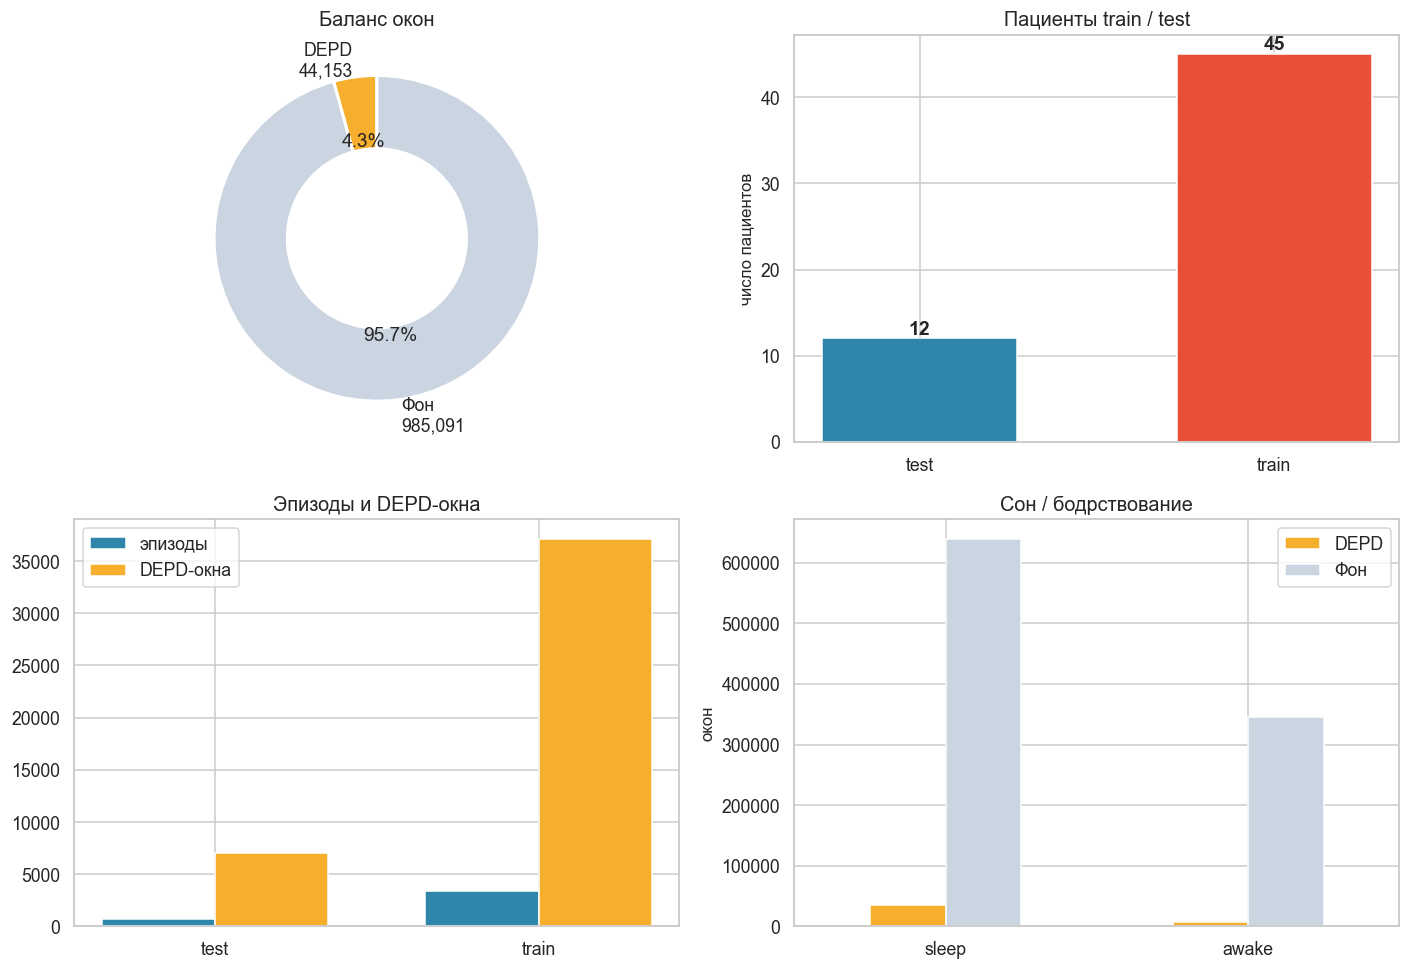

In [9]:
def save_fig(name: str) -> Path:
    path = FIGURES_DIR / name
    plt.savefig(path, bbox_inches="tight", facecolor="white")
    print(f"Saved: {path.name}")
    return path


fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1) Баланс классов (donut)
sizes = [has_depd.sum(), (~has_depd).sum()]
labels = [f"DEPD\n{sizes[0]:,}", f"Фон\n{sizes[1]:,}"]
wedges, texts, autotexts = axes[0, 0].pie(
    sizes,
    labels=labels,
    colors=[COLORS["depd"], COLORS["background"]],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45, "edgecolor": "white", "linewidth": 2},
)
axes[0, 0].set_title("Баланс окон")

# 2) Split по пациентам
split_pat = df_pat.groupby("split")["external_id"].count()
axes[0, 1].bar(
    split_pat.index,
    split_pat.values,
    color=[COLORS["train"], COLORS["test"]],
    width=0.55,
)
axes[0, 1].set_title("Пациенты train / test")
axes[0, 1].set_ylabel("число пациентов")
for i, v in enumerate(split_pat.values):
    axes[0, 1].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

# 3) Эпизоды и DEPD-окна по split
agg = df_pat.groupby("split")[["n_episodes", "n_depd"]].sum()
x = np.arange(len(agg))
w = 0.35
axes[1, 0].bar(x - w / 2, agg["n_episodes"], w, label="эпизоды", color=COLORS["train"])
axes[1, 0].bar(x + w / 2, agg["n_depd"], w, label="DEPD-окна", color=COLORS["depd"])
axes[1, 0].set_xticks(x, agg.index)
axes[1, 0].set_title("Эпизоды и DEPD-окна")
axes[1, 0].legend()

# 4) Sleep / awake среди DEPD vs фона
state_df = pd.DataFrame({
    "DEPD": [
        sum(m.get("state") == "sleep" for m in meta if m["has_depd"]),
        sum(m.get("state") == "awake" for m in meta if m["has_depd"]),
    ],
    "Фон": [
        sum(m.get("state") == "sleep" for m in meta if not m["has_depd"]),
        sum(m.get("state") == "awake" for m in meta if not m["has_depd"]),
    ],
}, index=["sleep", "awake"])
state_df.plot(kind="bar", ax=axes[1, 1], color=[COLORS["depd"], COLORS["background"]], rot=0)
axes[1, 1].set_title("Сон / бодрствование")
axes[1, 1].set_ylabel("окон")

plt.tight_layout()
save_fig("01_dashboard_overview.png")
plt.show()

Saved: 02_depd_timeline.png


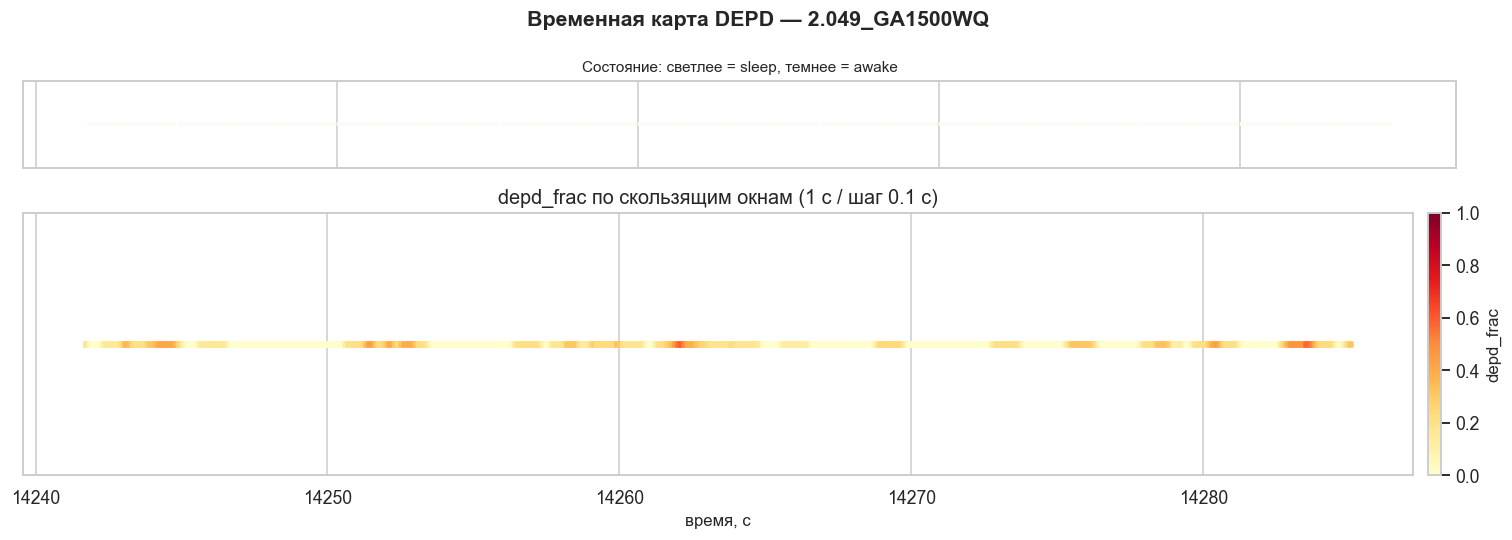

In [10]:
# --- Временная карта DEPD (одна запись) ---
DEMO_PATIENT = "2.049_GA1500WQ"  # test, высокая доля DEPD
rows = sorted(
    [m for m in meta if m["external_id"] == DEMO_PATIENT],
    key=lambda r: r["start_sec"],
)
step = max(1, len(rows) // 3000)
rows_ds = rows[::step]
t = np.array([r["start_sec"] for r in rows_ds])
frac = np.array([float(r["depd_frac"]) for r in rows_ds])
state_colors = np.array([
    1.0 if r.get("state") == "awake" else 0.55 for r in rows_ds
])

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True, gridspec_kw={"height_ratios": [1, 3]})
fig.suptitle(f"Временная карта DEPD — {DEMO_PATIENT}", fontsize=14, fontweight="bold")

# state ribbon
axes[0].scatter(t, np.ones_like(t), c=state_colors, cmap="Greens", s=8, marker="|")
axes[0].set_yticks([])
axes[0].set_title("Состояние: светлее = sleep, темнее = awake", fontsize=10)

# depd_frac heat strip
im = axes[1].scatter(
    t,
    np.zeros_like(t),
    c=frac,
    cmap="YlOrRd",
    s=12,
    marker="s",
    vmin=0,
    vmax=1,
)
axes[1].set_yticks([])
axes[1].set_xlabel("время, с")
axes[1].set_title("depd_frac по скользящим окнам (1 с / шаг 0.1 с)")
cbar = fig.colorbar(im, ax=axes[1], orientation="vertical", fraction=0.02, pad=0.01)
cbar.set_label("depd_frac")

plt.tight_layout()
save_fig("02_depd_timeline.png")
plt.show()

Saved: 03_eeg_examples.png


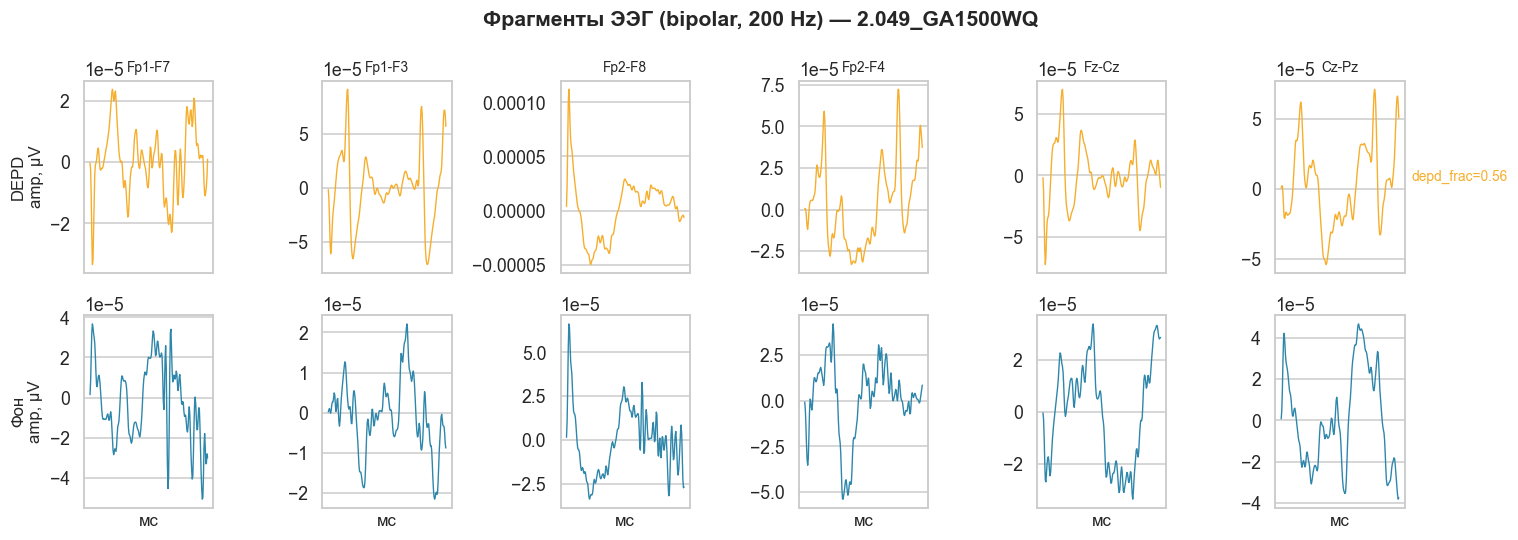

In [11]:
# --- Примеры ЭЭГ: DEPD vs фон ---
from riemann_new_format.dataset import NewFormatDataset

ds = NewFormatDataset(DATA_DIR, feature_names=())

depd_idx = next(
    i for i, m in enumerate(meta)
    if m["external_id"] == DEMO_PATIENT and m["has_depd"] and float(m["depd_frac"]) >= 0.5
)
bg_idx = next(
    i for i, m in enumerate(meta)
    if m["external_id"] == DEMO_PATIENT and not m["has_depd"]
)

idx = np.array([depd_idx, bg_idx], dtype=np.int64)
X = ds.get_batch(idx)
t_ms = np.arange(X.shape[2]) / 200 * 1000
show_ch = [0, 4, 8, 12, 16, 17]
depd_frac_val = float(meta[depd_idx]["depd_frac"])

fig, axes = plt.subplots(2, len(show_ch), figsize=(14, 5), sharex=True)
fig.suptitle(
    f"Фрагменты ЭЭГ (bipolar, 200 Hz) — {DEMO_PATIENT}",
    fontsize=14,
    fontweight="bold",
)

for col, ch in enumerate(show_ch):
    axes[0, col].plot(t_ms, X[0, ch], color=COLORS["depd"], lw=0.9)
    axes[1, col].plot(t_ms, X[1, ch], color=COLORS["train"], lw=0.9)
    axes[0, col].set_title(CH_NAMES[ch], fontsize=9)
    axes[0, col].set_xticks([])
    axes[1, col].set_xlabel("мс")

axes[0, 0].set_ylabel("DEPD\namp, µV")
axes[1, 0].set_ylabel("Фон\namp, µV")
axes[0, -1].text(
    1.05, 0.5,
    f"depd_frac={depd_frac_val:.2f}",
    transform=axes[0, -1].transAxes,
    va="center",
    fontsize=9,
    color=COLORS["depd"],
)

plt.tight_layout()
save_fig("03_eeg_examples.png")
plt.show()

Saved: 04_top_patients.png


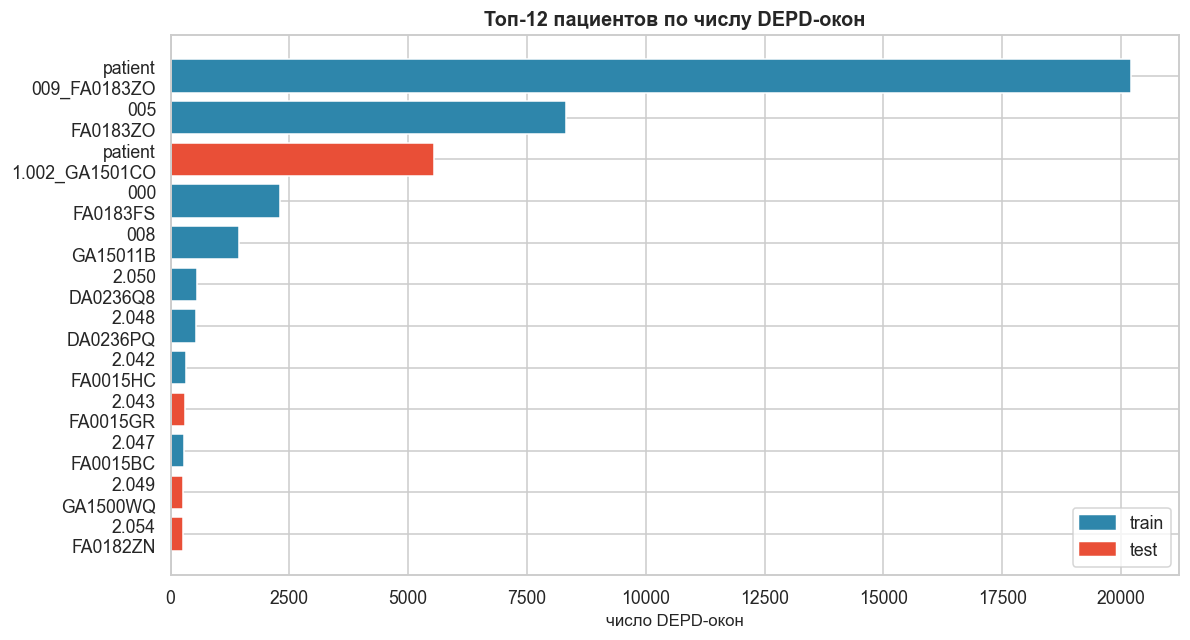

In [12]:
# --- Top-12 пациентов по числу DEPD-окон ---
top = df_pat.nlargest(12, "n_depd").copy()
top["label"] = top["external_id"].str.replace("_", "\n", n=1)
bar_colors = top["split"].map({"train": COLORS["train"], "test": COLORS["test"]})

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top["label"], top["n_depd"], color=bar_colors, edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("число DEPD-окон")
ax.set_title("Топ-12 пациентов по числу DEPD-окон", fontweight="bold")
ax.legend(
    handles=[
        mpatches.Patch(color=COLORS["train"], label="train"),
        mpatches.Patch(color=COLORS["test"], label="test"),
    ],
    loc="lower right",
)
plt.tight_layout()
save_fig("04_top_patients.png")
plt.show()

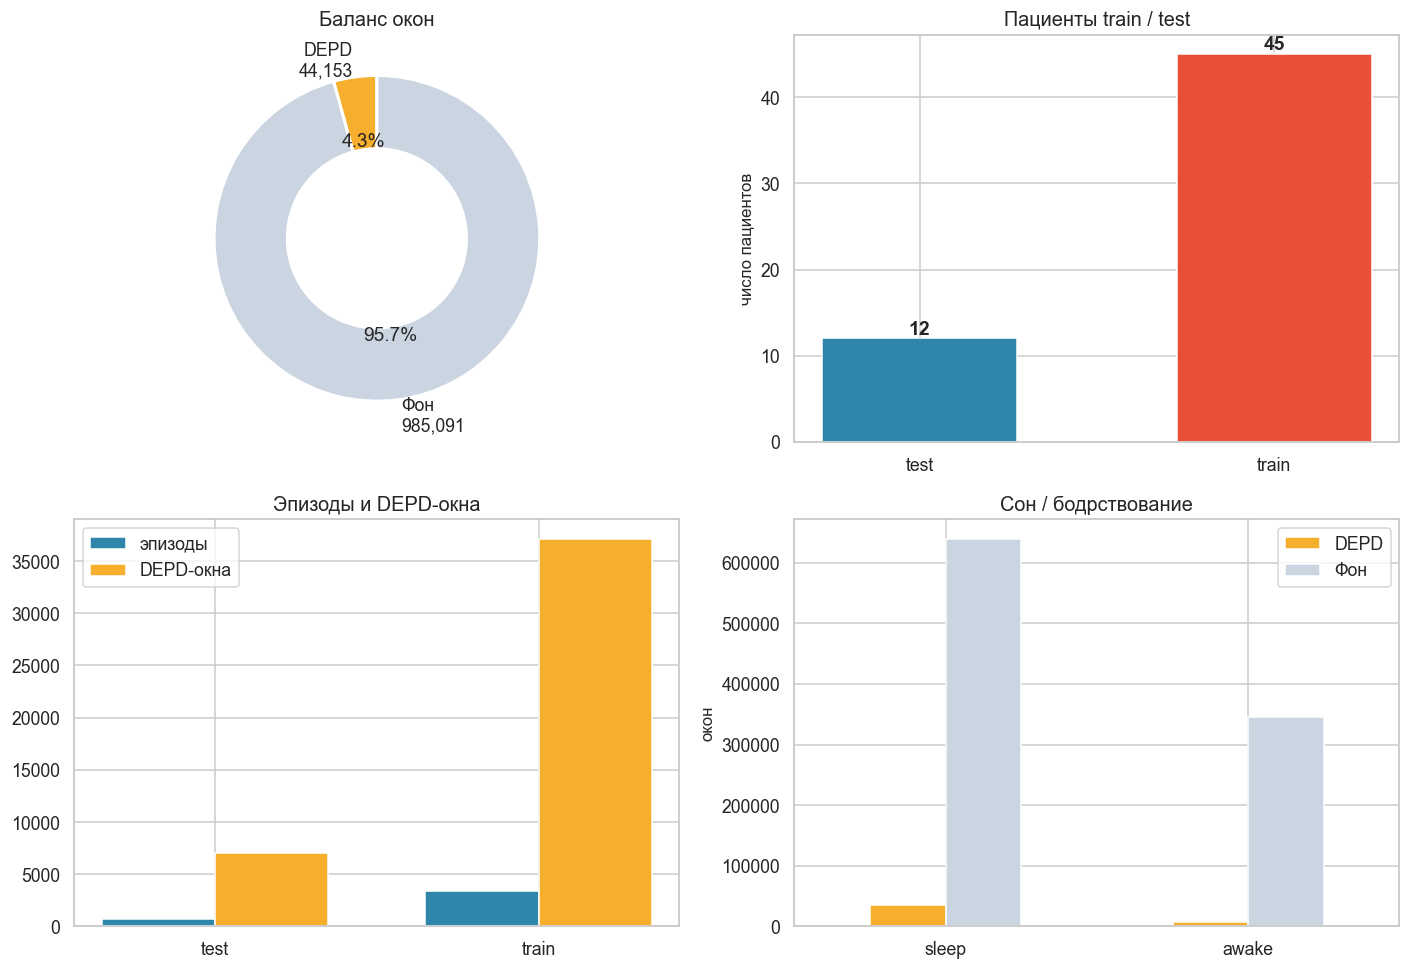

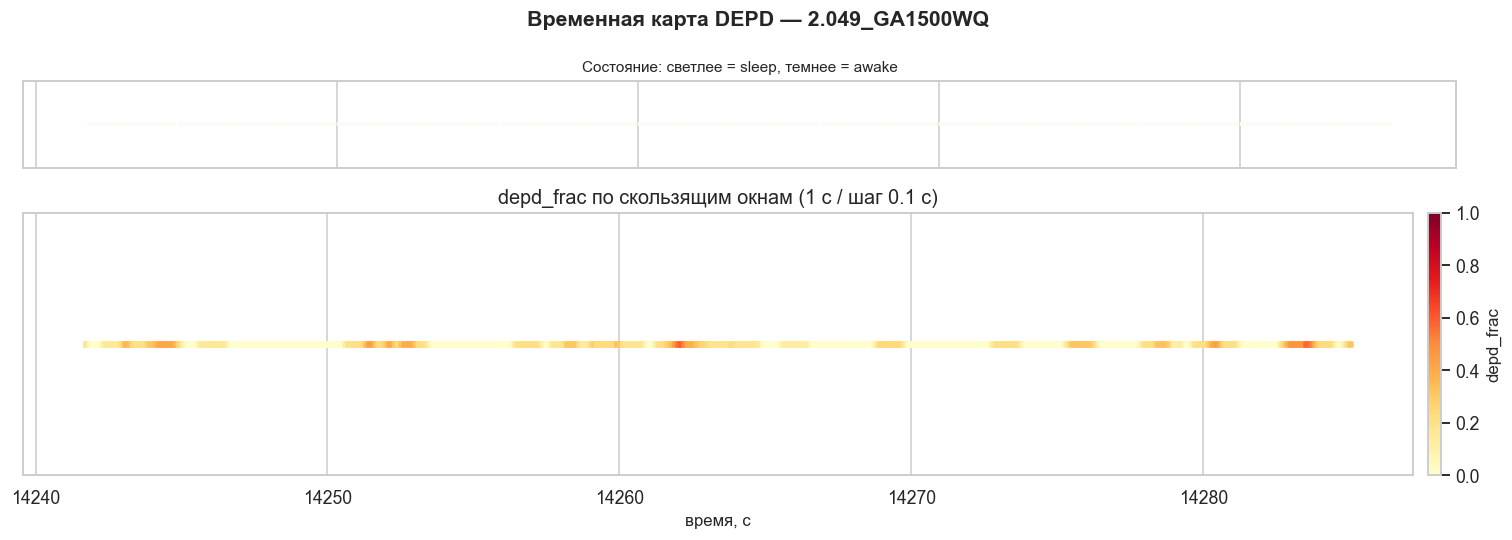

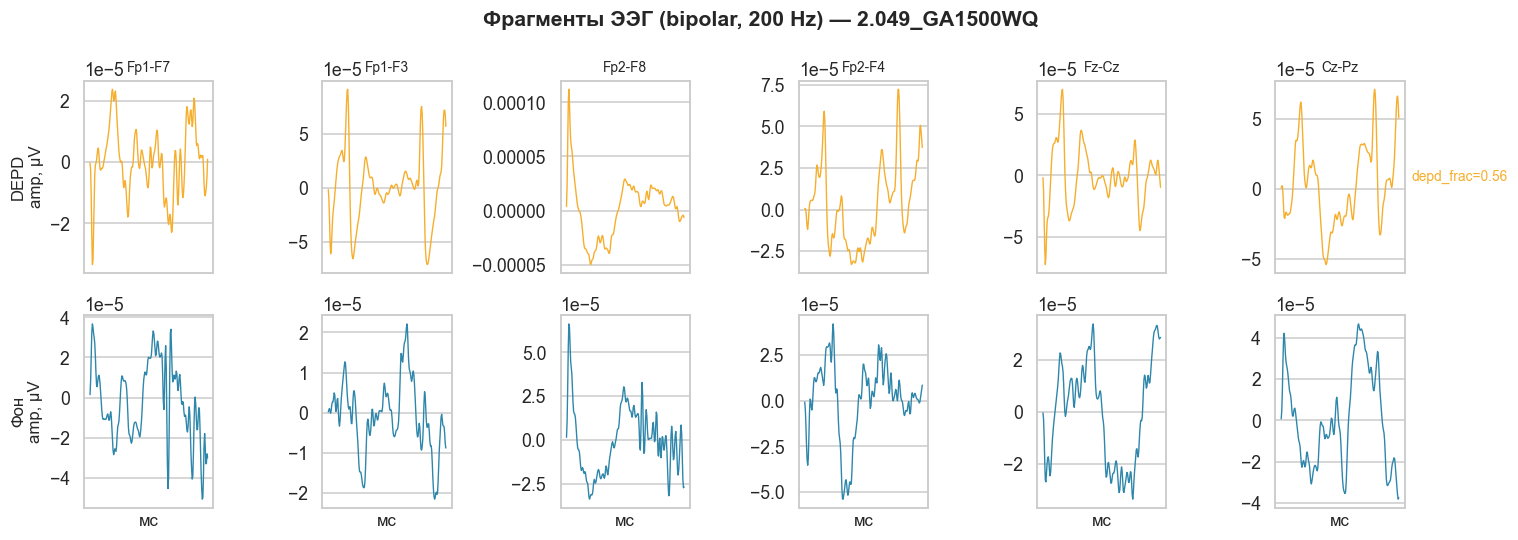

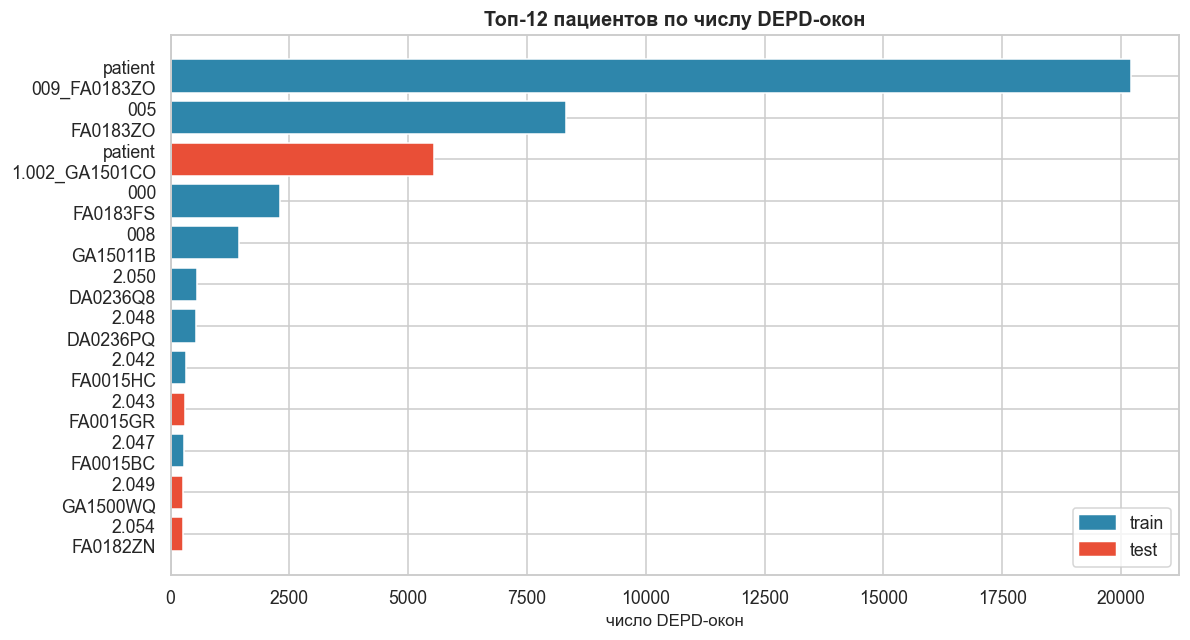

In [13]:
for path in sorted(FIGURES_DIR.glob("*.png")):
    display(Image(filename=str(path), width=680))